# AN7914 — Data Analytics and Modelling A
### Lending Club: Determinants of Interest Rates


|---|---|
| **Student ID** | |
| **Module** | AN7914 — Data Analytics and Modelling A |
| **University** | University of Winchester |
| **Dataset** | loans_dataset_4473645.csv |


## Setup

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlepad': 12})
os.makedirs('figures', exist_ok=True)

# Colour palette used throughout all figures 
C = {
    'blue'   : '#4361EE',
    'red'    : '#E63946',
    'teal'   : '#2EC4B6',
    'amber'  : "#AF6A09",
    'purple' : "#955FB9",
    'green'  : '#3A9E5F',
    'slate'  : '#3D405B',
}

raw = pd.read_csv('C:/User/Desktop/AN7914/data/loans_dataset_4473645.csv')
print(f"Raw dataset loaded → {raw.shape[0]:,} rows  ×  {raw.shape[1]} columns")

Raw dataset loaded → 10,000 rows  ×  55 columns


## Part A · Data Preparation

### A(a) Subset the Data

In [162]:
keep = [
    'interest_rate', 'verified_income', 'debt_to_income',
    'total_credit_utilized', 'total_credit_limit', 'public_record_bankrupt',
    'loan_purpose', 'term', 'inquiries_last_12m',
    'issue_month', 'annual_income', 'loan_amount',
    'grade', 'emp_length', 'homeownership'
]
df = raw[keep].copy()
print(f"Subset  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("Retained columns:", keep)

Subset  →  10,000 rows  ×  15 columns
Retained columns: ['interest_rate', 'verified_income', 'debt_to_income', 'total_credit_utilized', 'total_credit_limit', 'public_record_bankrupt', 'loan_purpose', 'term', 'inquiries_last_12m', 'issue_month', 'annual_income', 'loan_amount', 'grade', 'emp_length', 'homeownership']


### A(b) Rename Column

In [163]:
df.rename(columns={'inquiries_last_12m': 'credit_checks'}, inplace=True)
print("inquiries_last_12m  →  credit_checks")
print("Columns now:", list(df.columns))

inquiries_last_12m  →  credit_checks
Columns now: ['interest_rate', 'verified_income', 'debt_to_income', 'total_credit_utilized', 'total_credit_limit', 'public_record_bankrupt', 'loan_purpose', 'term', 'credit_checks', 'issue_month', 'annual_income', 'loan_amount', 'grade', 'emp_length', 'homeownership']


In [ ]:
num_cols = df.select_dtypes(include='number').columns
summary  = df[num_cols].describe().T[['count','mean','std','min','max']].round(3)
summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', 'Max']
print("Summary Statistics: Numerical Variables")
print(summary.to_string())

── Summary Statistics: Numerical Variables ──────────────────
                          Count        Mean     Std Dev      Min         Max
interest_rate           10000.0      12.428       5.001     5.31       30.94
debt_to_income           9976.0      19.308      15.005     0.00      469.09
total_credit_utilized   10000.0   51049.063   53636.731     0.00   942456.00
total_credit_limit      10000.0  183606.230  187632.708     0.00  3386034.00
public_record_bankrupt  10000.0       0.124       0.337     0.00        3.00
term                    10000.0      43.272      11.030    36.00       60.00
credit_checks           10000.0       1.958       2.380     0.00       29.00
annual_income           10000.0   79222.148   64734.290     0.00  2300000.00
loan_amount             10000.0   16361.922   10301.957  1000.00    40000.00
emp_length               9183.0       5.930       3.704     0.00       10.00


In [166]:
mv = df.isnull().sum()
mv = pd.DataFrame({'Missing': mv, 'Pct (%)': (mv/len(df)*100).round(2)})
mv = mv[mv['Missing'] > 0]
print("Missing Value Report")
print(mv.to_string())

Missing Value Report
                Missing  Pct (%)
debt_to_income       24     0.24
emp_length          817     8.17


In [167]:
# emp_length (8.17%) → median imputation
med = df['emp_length'].median()
df['emp_length'].fillna(med, inplace=True)
print(f"emp_length    : 817 NaNs filled with median = {med:.0f} years")

# debt_to_income (0.24%) → row deletion
n_before = len(df)
df.dropna(subset=['debt_to_income'], inplace=True)
print(f"debt_to_income: {n_before - len(df)} rows dropped")
print()
print(f"Clean dataset  →  {len(df):,} rows  x  {df.shape[1]} columns")
print(f"Remaining NaNs : {df.isnull().sum().sum()}")

emp_length    : 817 NaNs filled with median = 6 years
debt_to_income: 24 rows dropped

Clean dataset  →  9,976 rows  x  15 columns
Remaining NaNs : 0


## Part B · Exploratory Data Analysis

### 2.1(a)Descriptive Statistics

In [168]:
cols4 = ['interest_rate', 'annual_income', 'debt_to_income', 'loan_amount']
tbl   = df[cols4].agg(['mean','median','std','min','max']).T.round(2)
tbl.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
tbl.index   = ['Interest Rate (%)', 'Annual Income ($)',
                'Debt-to-Income Ratio', 'Loan Amount ($)']
print("Table 1 — Descriptive Statistics: Key Numerical Variables")
print(tbl.to_string())

Table 1 — Descriptive Statistics: Key Numerical Variables
                          Mean    Median   Std Dev      Min         Max
Interest Rate (%)        12.42     11.98      5.00     5.31       30.94
Annual Income ($)     79412.74  65000.00  64695.24  3000.00  2300000.00
Debt-to-Income Ratio     19.31     17.57     15.00     0.00      469.09
Loan Amount ($)       16357.53  14500.00  10301.61  1000.00    40000.00


### 2.1(b)Categorical Frequency Tables

In [169]:
for col in ['grade', 'verified_income', 'homeownership']:
    tbl = df[col].value_counts().reset_index()
    tbl.columns = ['Category', 'Count']
    tbl['Pct (%)'] = (tbl['Count'] / len(df) * 100).round(2)
    if col == 'grade':
        tbl = tbl.sort_values('Category')
    print(f"\n{col.replace('_',' ').title()}  ({df[col].nunique()} categories)")
    print(tbl.to_string(index=False))


Grade  (7 categories)
Category  Count  Pct (%)
       A   2454    24.60
       B   3032    30.39
       C   2649    26.55
       D   1438    14.41
       E    334     3.35
       F     57     0.57
       G     12     0.12

Verified Income  (3 categories)
       Category  Count  Pct (%)
Source Verified   4115    41.25
   Not Verified   3573    35.82
       Verified   2288    22.94

Homeownership  (3 categories)
Category  Count  Pct (%)
MORTGAGE   4778    47.89
    RENT   3848    38.57
     OWN   1350    13.53


### 2.2(a)Histograms

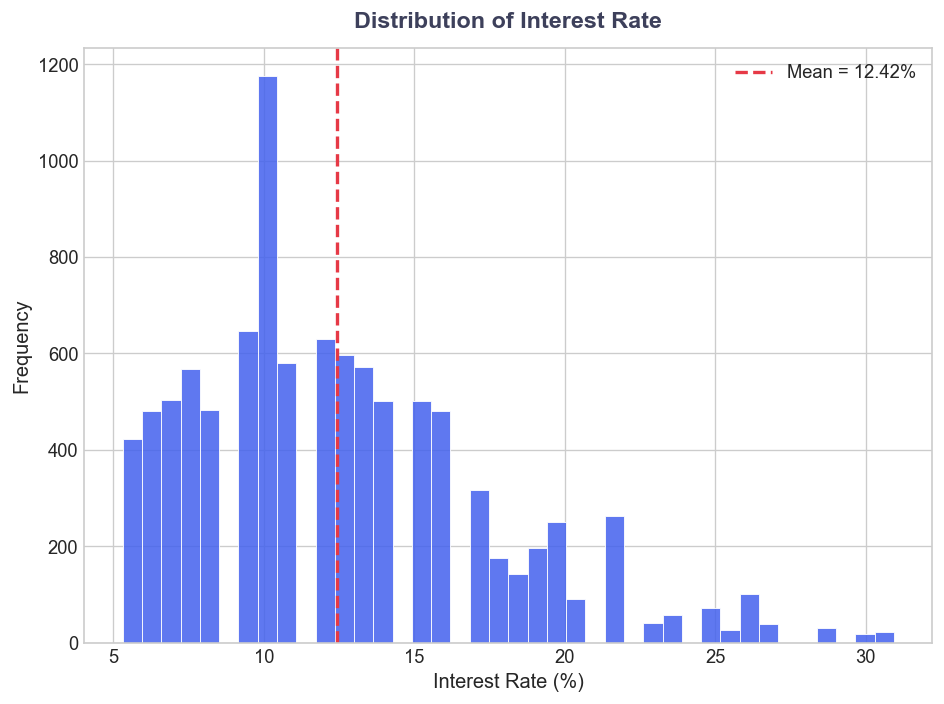

Figure 1 saved.


In [170]:
# Figure 1 · Interest Rate Distribution
fig, ax = plt.subplots(figsize=(8, 6))
n, bins, patches = ax.hist(df['interest_rate'], bins=40,
                            color=C['blue'], edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(df['interest_rate'].mean(), color=C['red'], linestyle='--',
           linewidth=2, label=f"Mean = {df['interest_rate'].mean():.2f}%")
ax.set_title('Distribution of Interest Rate', fontsize=14, fontweight='bold', color=C['slate'])
ax.set_xlabel('Interest Rate (%)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig1_interest_rate_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

**Figure 1:** Interest rates are right-skewed with the bulk of loans clustered between 5–20%; a small tail of high-risk borrowers attracts rates above 25%.

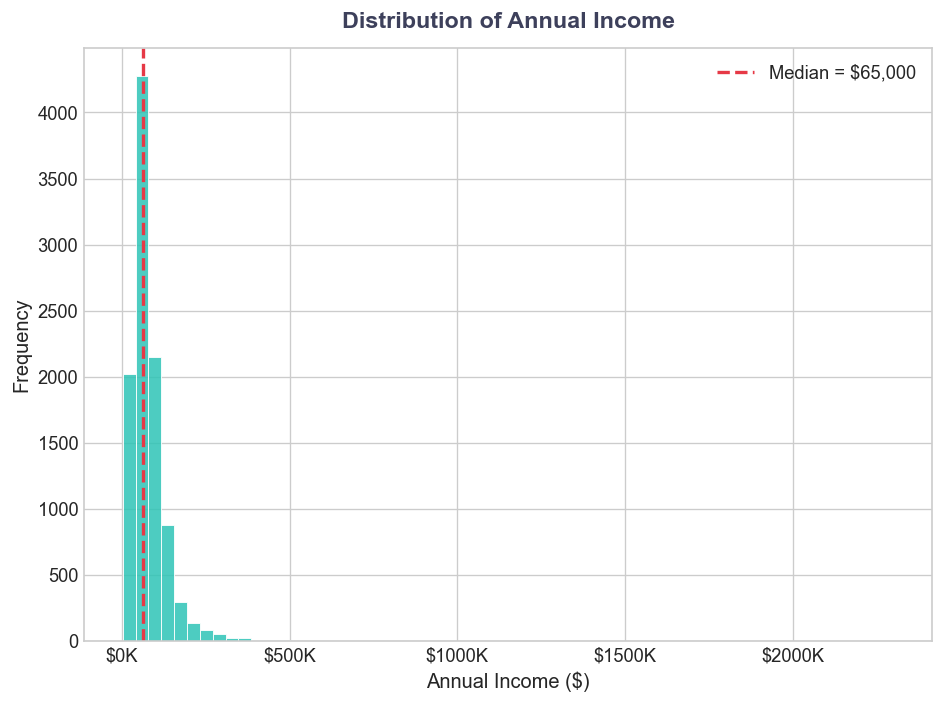

Figure 2 saved.


In [171]:
# Figure 2 · Annual Income Distribution
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df['annual_income'], bins=60,
        color=C['teal'], edgecolor='white', linewidth=0.6, alpha=0.85)
med_inc = df['annual_income'].median()
ax.axvline(med_inc, color=C['red'], linestyle='--', linewidth=2,
           label=f"Median = ${med_inc:,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Distribution of Annual Income', fontsize=14, fontweight='bold', color=C['slate'])
ax.set_xlabel('Annual Income ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig2_annual_income_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

**Figure 2:** Annual income is strongly right-skewed; most borrowers earn below $100K while extreme outliers up to $2.3M pull the mean well above the median.

### 2.2(b)Scatterplots

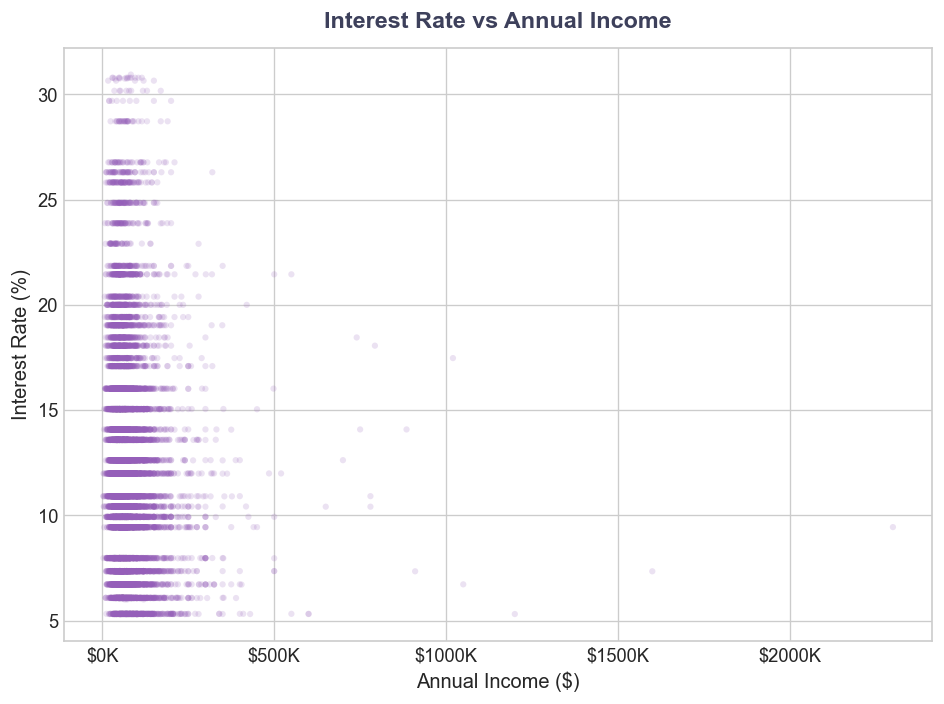

Figure 3 saved.


In [172]:
# Figure 3 · Interest Rate vs Annual Income
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['annual_income'], df['interest_rate'],
           alpha=0.18, s=14, color=C['purple'], edgecolors='none')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Interest Rate vs Annual Income', fontsize=14, fontweight='bold', color=C['slate'])
ax.set_xlabel('Annual Income ($)', fontsize=12)
ax.set_ylabel('Interest Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig3_scatter_ir_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

**Figure 3:** No strong linear relationship is visible; wide vertical scatter at low income levels suggests annual income is a weak standalone predictor of interest rate.

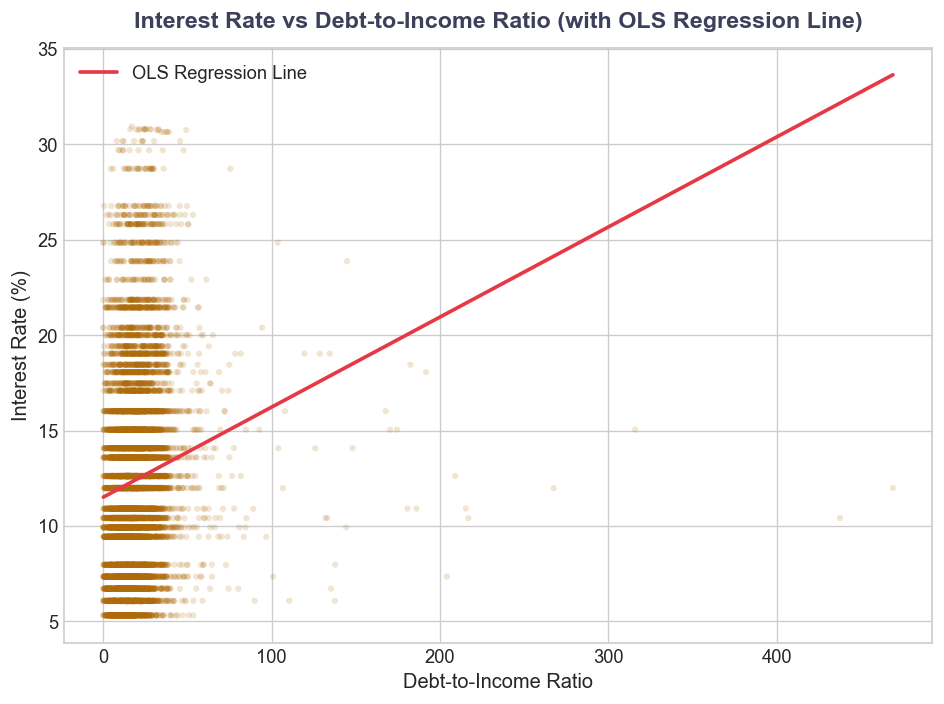

Figure 4 saved.


In [173]:
# Figure 4 · Interest Rate vs DTI + OLS line
dfs = df[["debt_to_income","interest_rate"]].dropna()
Xs  = sm.add_constant(dfs["debt_to_income"])
fit = sm.OLS(dfs["interest_rate"], Xs).fit()
xl  = np.linspace(dfs["debt_to_income"].min(), dfs["debt_to_income"].max(), 200)
yl  = fit.params["const"] + fit.params["debt_to_income"] * xl

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dfs["debt_to_income"], dfs["interest_rate"],
           alpha=0.18, s=14, color=C["amber"], edgecolors="none")
ax.plot(xl, yl, color=C["red"], linewidth=2.2, label="OLS Regression Line")
ax.set_title("Interest Rate vs Debt-to-Income Ratio (with OLS Regression Line)",
             fontsize=14, fontweight="bold", color=C["slate"])
ax.set_xlabel("Debt-to-Income Ratio", fontsize=12)
ax.set_ylabel("Interest Rate (%)", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig4_scatter_ir_dti.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

**Figure 4:** The upward OLS line confirms a positive DTI–rate relationship; borrowers with heavier debt burdens relative to income are charged higher rates, consistent with default-risk pricing.

### 2.2(c)Boxplots

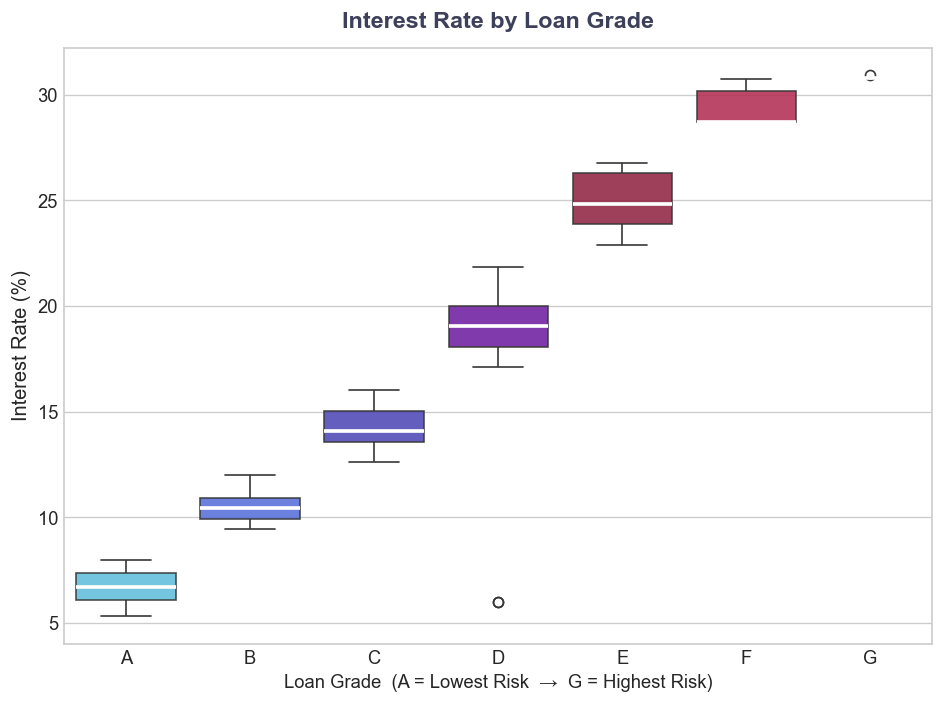

Figure 5 saved.


In [174]:
# Figure 5 · Interest Rate by Loan Grade
grade_palette = ['#4CC9F0','#4361EE','#3F37C9','#7209B7','#A4133C','#C9184A','#FF4D6D']
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='grade', y='interest_rate',
            order=['A','B','C','D','E','F','G'],
            palette=grade_palette, ax=ax,
            medianprops=dict(color='white', linewidth=2.2),
            boxprops=dict(alpha=0.88))
ax.set_title('Interest Rate by Loan Grade', fontsize=14, fontweight='bold', color=C['slate'])
ax.set_xlabel('Loan Grade  (A = Lowest Risk  →  G = Highest Risk)', fontsize=11)
ax.set_ylabel('Interest Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig5_boxplot_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

**Figure 5:** Median interest rates rise monotonically from Grade A to G, confirming that Lending Club's internal grade is the dominant driver of the rate assigned.

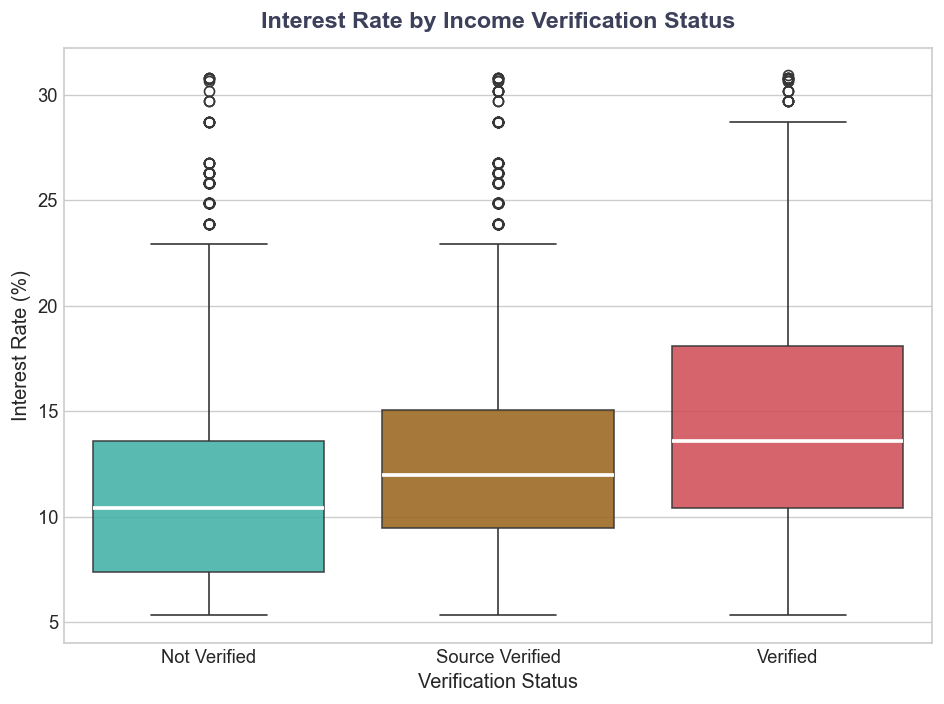

Figure 6 saved.


In [175]:
# Figure 6 · Interest Rate by Income Verification Status
vi_palette = [C['teal'], C['amber'], C['red']]
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='verified_income', y='interest_rate',
            order=['Not Verified','Source Verified','Verified'],
            palette=vi_palette, ax=ax,
            medianprops=dict(color='white', linewidth=2.2),
            boxprops=dict(alpha=0.88))
ax.set_title('Interest Rate by Income Verification Status',
             fontsize=14, fontweight='bold', color=C['slate'])
ax.set_xlabel('Verification Status', fontsize=12)
ax.set_ylabel('Interest Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig6_boxplot_verified.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

**Figure 6:** Verified borrowers face higher median rates than unverified ones — a counter-intuitive result likely driven by selection bias, where lenders request verification for riskier applicants.

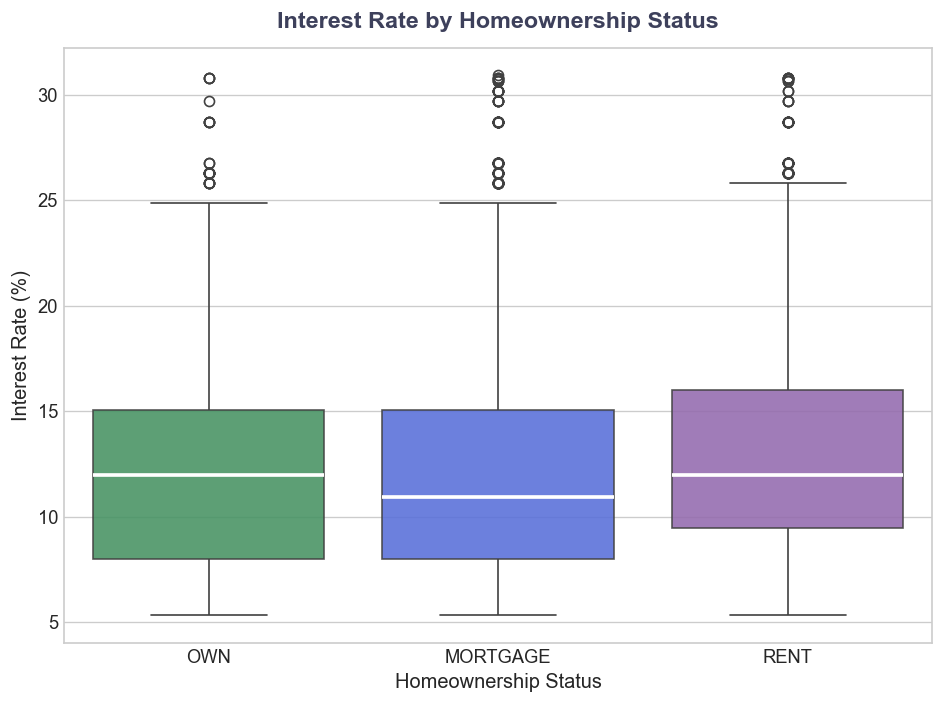

Figure 7 saved.


In [176]:
# Figure 7 · Interest Rate by Homeownership Status
ho_palette = [C['green'], C['blue'], C['purple']]
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='homeownership', y='interest_rate',
            order=['OWN','MORTGAGE','RENT'],
            palette=ho_palette, ax=ax,
            medianprops=dict(color='white', linewidth=2.2),
            boxprops=dict(alpha=0.88))
ax.set_title('Interest Rate by Homeownership Status',
             fontsize=14, fontweight='bold', color=C['slate'])
ax.set_xlabel('Homeownership Status', fontsize=12)
ax.set_ylabel('Interest Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig7_boxplot_homeownership.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

**Figure 7:** Renters carry slightly higher median rates than owners and mortgage holders, suggesting that property ownership acts as a signal of financial stability to lenders.

### 2.3 Feature Engineering

In [177]:
# (a) Credit Utilisation Ratio  —  safe division (0 where limit = 0)
df['credit_util'] = np.where(
    df['total_credit_limit'] == 0, 0,
    df['total_credit_utilized'] / df['total_credit_limit']
)
mu_cu  = df['credit_util'].mean()
pct_cu = (df['credit_util'] > 0).mean() * 100
print(f"credit_util       →  mean = {mu_cu:.4f} ({mu_cu*100:.2f}%)   non-zero = {pct_cu:.2f}%")

credit_util       →  mean = 0.4030 (40.30%)   non-zero = 99.72%


In [178]:
# (b) Bankruptcy Indicator  —  1 if any public bankruptcy record, else 0
df['bankruptcy_dummy'] = (df['public_record_bankrupt'] >= 1).astype(int)
mu_bd  = df['bankruptcy_dummy'].mean()
pct_bd = (df['bankruptcy_dummy'] > 0).mean() * 100
print(f"bankruptcy_dummy  →  mean = {mu_bd:.4f}          non-zero = {pct_bd:.2f}%")

summary_fe = pd.DataFrame({
    'Variable'    : ['credit_util', 'bankruptcy_dummy'],
    'Description' : ['Credit Utilization Ratio', 'Bankruptcy Indicator (1 = yes)'],
    'Mean'        : [round(mu_cu, 4), round(mu_bd, 4)],
    '% Non-Zero'  : [round(pct_cu, 2), round(pct_bd, 2)]
})
print()
print(summary_fe.to_string(index=False))
print(f"\nDataframe  →  {df.shape[1]} columns total")

bankruptcy_dummy  →  mean = 0.1216          non-zero = 12.16%

        Variable                    Description   Mean  % Non-Zero
     credit_util       Credit Utilization Ratio 0.4030       99.72
bankruptcy_dummy Bankruptcy Indicator (1 = yes) 0.1216       12.16

Dataframe  →  17 columns total


## Part C · Regression Analysis

In [179]:
# Build regression-ready dataset
reg_vars = [
    'interest_rate', 'debt_to_income', 'credit_util', 'bankruptcy_dummy',
    'annual_income', 'loan_amount', 'term', 'grade',
    'emp_length', 'homeownership', 'loan_purpose', 'credit_checks', 'verified_income'
]
df_reg = df[reg_vars].dropna().copy()
y      = df_reg['interest_rate']
print(f"Regression sample  →  {len(df_reg):,} observations")

Regression sample  →  9,976 observations


### Model 1 Simple Linear Regression


In [180]:
X1     = sm.add_constant(df_reg['debt_to_income'])
mdl1   = sm.OLS(y, X1).fit()
print(mdl1.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     204.2
Date:                Thu, 14 May 2026   Prob (F-statistic):           7.05e-46
Time:                        21:50:18   Log-Likelihood:                -30105.
No. Observations:                9976   AIC:                         6.021e+04
Df Residuals:                    9974   BIC:                         6.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.5114      0.081    142.

In [181]:
b0, b1, p1 = mdl1.params['const'], mdl1.params['debt_to_income'], mdl1.pvalues['debt_to_income']
print(f"  Fitted equation")
print(f"  interest_rate = {b0:.4f} + {b1:.4f} × debt_to_income")
print()
print(f"  β₁ interpretation")
print(f"  Each 1-unit rise in DTI → +{b1:.4f} pp in interest rate (ceteris paribus).")
print()
print(f"  Hypothesis test   H₀: β₁ = 0   p = {p1:.4f}")
print(f"  {'':4} 10% level : {'REJECT H₀' if p1<0.10 else 'FAIL TO REJECT'}")
print(f"  {'':4}  5% level : {'REJECT H₀' if p1<0.05 else 'FAIL TO REJECT'}")
print(f"  {'':4}  1% level : {'REJECT H₀' if p1<0.01 else 'FAIL TO REJECT'}")


  Fitted equation
  interest_rate = 11.5114 + 0.0472 × debt_to_income

  β₁ interpretation
  Each 1-unit rise in DTI → +0.0472 pp in interest rate (ceteris paribus).

  Hypothesis test   H₀: β₁ = 0   p = 0.0000
       10% level : REJECT H₀
        5% level : REJECT H₀
        1% level : REJECT H₀


**Result:** DTI is significant at all levels; higher debt burden relative to income is associated with higher lending rates, consistent with default-risk pricing theory.

### Model 2 Simple Linear Regression


In [191]:
X2   = sm.add_constant(df_reg['bankruptcy_dummy'])
mdl2 = sm.OLS(y, X2).fit()
print(mdl2.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     23.04
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.61e-06
Time:                        21:52:30   Log-Likelihood:                -30195.
No. Observations:                9976   AIC:                         6.039e+04
Df Residuals:                    9974   BIC:                         6.041e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               12.3332      0.053  

In [192]:
b0, b1, p1 = mdl2.params['const'], mdl2.params['bankruptcy_dummy'], mdl2.pvalues['bankruptcy_dummy']
print(f"  Fitted equation")
print(f"  interest_rate = {b0:.4f} + {b1:.4f} × bankruptcy_dummy")
print()
print(f"  β₁ interpretation")
print(f"  Borrowers with a bankruptcy record pay {b1:.4f} pp MORE on average")
print(f"  than borrowers with no bankruptcy history.")
print()
print(f"  Hypothesis test   H₀: β₁ = 0   p = {p1:.4f}")
print(f"  {'':4} 10% level : {'REJECT H₀' if p1<0.10 else 'FAIL TO REJECT'}")
print(f"  {'':4}  5% level : {'REJECT H₀' if p1<0.05 else 'FAIL TO REJECT'}")
print(f"  {'':4}  1% level : {'REJECT H₀' if p1<0.01 else 'FAIL TO REJECT'}")


  Fitted equation
  interest_rate = 12.3332 + 0.7341 × bankruptcy_dummy

  β₁ interpretation
  Borrowers with a bankruptcy record pay 0.7341 pp MORE on average
  than borrowers with no bankruptcy history.

  Hypothesis test   H₀: β₁ = 0   p = 0.0000
       10% level : REJECT H₀
        5% level : REJECT H₀
        1% level : REJECT H₀


**Result:** Bankruptcy history is a significant predictor; past defaults signal elevated credit risk, leading lenders to price in a rate premium.

### Model 3 Categorical Variable Regression
> **Specification:**  interest\_rate = β₀ + β₁D₁ + β₂D₂ + ε  
> **Reference category:** *Not Verified*


In [184]:
# Create dummies — reference = 'Not Verified' (dropped)
dvi = pd.get_dummies(df_reg['verified_income'], drop_first=False)
dvi = dvi.drop(columns=['Not Verified']).rename(
        columns={'Source Verified': 'D1_Source_Verified', 'Verified': 'D2_Verified'})
dvi = dvi.astype(int)

X3   = sm.add_constant(dvi)
mdl3 = sm.OLS(y, X3).fit()
print(mdl3.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     321.7
Date:                Thu, 14 May 2026   Prob (F-statistic):          3.92e-136
Time:                        21:50:18   Log-Likelihood:                -29895.
No. Observations:                9976   AIC:                         5.980e+04
Df Residuals:                    9973   BIC:                         5.982e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 11.0749      0

In [185]:
b0 = mdl3.params['const']
b1 = mdl3.params['D1_Source_Verified']
b2 = mdl3.params['D2_Verified']

print(f"  Fitted equation")
print(f"  interest_rate = {b0:.4f} + {b1:.4f}·D1_SourceVerified + {b2:.4f}·D2_Verified")
print()
print(f"  Reference category → 'Not Verified'")
print(f"  Predicted avg rate for 'Not Verified' = β₀ = {b0:.4f}%")
print()
print(f"  β₁  Source Verified vs Not Verified  :  +{b1:.4f} pp")
print(f"  β₂  Verified vs Not Verified         :  +{b2:.4f} pp")


  Fitted equation
  interest_rate = 11.0749 + 1.4411·D1_SourceVerified + 3.2838·D2_Verified

  Reference category → 'Not Verified'
  Predicted avg rate for 'Not Verified' = β₀ = 11.0749%

  β₁  Source Verified vs Not Verified  :  +1.4411 pp
  β₂  Verified vs Not Verified         :  +3.2838 pp


**Result:** Both verified categories carry significantly higher rates, likely reflecting lender selection bias — income is verified more often for higher-risk borrowers.

### Model 4  Multiple Regression

In [186]:
X4   = sm.add_constant(df_reg[['debt_to_income', 'credit_util', 'bankruptcy_dummy']])
mdl4 = sm.OLS(y, X4).fit()
print(mdl4.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     279.9
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.85e-174
Time:                        21:50:18   Log-Likelihood:                -29803.
No. Observations:                9976   AIC:                         5.961e+04
Df Residuals:                    9972   BIC:                         5.964e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                9.8708      0.102  

In [187]:
dti_m1 = mdl1.params['debt_to_income']
dti_m4 = mdl4.params['debt_to_income']
cu_m4  = mdl4.params['credit_util']

print(f"  DTI coefficient change")
print(f"  Model 1  :  {dti_m1:.4f}")
print(f"  Model 4  :  {dti_m4:.4f}   (Δ = {dti_m4 - dti_m1:+.4f})")
print()
print(f"  Why it changed:")
print(f"  In Model 1, DTI absorbed variation also driven by credit_util")
print(f"  and bankruptcy_dummy. Adding these controls corrects the")
print(f"  omitted variable bias and isolates the partial effect of DTI.")
print()
print(f"  credit_util coefficient")
print(f"  A 1-unit rise in credit utilisation → +{cu_m4:.4f} pp interest rate,")
print(f"  holding DTI and bankruptcy constant.")

  DTI coefficient change
  Model 1  :  0.0472
  Model 4  :  0.0365   (Δ = -0.0107)

  Why it changed:
  In Model 1, DTI absorbed variation also driven by credit_util
  and bankruptcy_dummy. Adding these controls corrects the
  omitted variable bias and isolates the partial effect of DTI.

  credit_util coefficient
  A 1-unit rise in credit utilisation → +4.4113 pp interest rate,
  holding DTI and bankruptcy constant.


**Result:** DTI falls when controls are added, confirming upward omitted-variable bias in Model 1; credit utilisation is the strongest predictor in this specification.

### Model 5 Full Specification


In [188]:
# Explicit reference-category ordering
df_reg['grade'] = pd.Categorical(
    df_reg['grade'], categories=['A','B','C','D','E','F','G'], ordered=True)
df_reg['homeownership'] = pd.Categorical(
    df_reg['homeownership'], categories=['MORTGAGE','OWN','RENT'], ordered=False)
df_reg['loan_purpose'] = pd.Categorical(
    df_reg['loan_purpose'], categories=sorted(df_reg['loan_purpose'].unique()), ordered=False)

dum5 = pd.get_dummies(df_reg[['grade','homeownership','loan_purpose']],
                      drop_first=True).astype(int)
cont5 = df_reg[['debt_to_income','credit_util','bankruptcy_dummy',
                'annual_income','loan_amount','term','emp_length','credit_checks']]

X5   = sm.add_constant(pd.concat([cont5, dum5], axis=1))
mdl5 = sm.OLS(y.loc[df_reg.index], X5).fit()
print(mdl5.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     7277.
Date:                Thu, 14 May 2026   Prob (F-statistic):               0.00
Time:                        21:50:18   Log-Likelihood:                -15080.
No. Observations:                9976   AIC:                         3.022e+04
Df Residuals:                    9948   BIC:                         3.042e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [189]:
actual    = y.loc[df_reg.index]
predicted = mdl5.fittedvalues
resids    = mdl5.resid

resid_tbl = pd.DataFrame({
    'Actual'   : actual.values[:5].round(4),
    'Predicted': predicted.values[:5].round(4),
    'Residual' : resids.values[:5].round(4)
}, index=[f'Obs {i+1}' for i in range(5)])


print("  Reference categories")
print("    grade         : A  (best credit quality)")
print("    homeownership : MORTGAGE")
print("    loan_purpose  : car  (alphabetically first)")
print()
print("  Residuals — first five observations")
print(resid_tbl.to_string())
print()
print(f"  R²     = {mdl5.rsquared:.4f}")
print(f"  Adj R² = {mdl5.rsquared_adj:.4f}")
print(f"  F-stat = {mdl5.fvalue:.2f}   (p < 0.0001)")


  Reference categories
    grade         : A  (best credit quality)
    homeownership : MORTGAGE
    loan_purpose  : car  (alphabetically first)

  Residuals — first five observations
       Actual  Predicted  Residual
Obs 1   14.07    14.3378   -0.2678
Obs 2   12.61    14.0321   -1.4221
Obs 3   17.09    19.1933   -2.1033
Obs 4    6.72     6.7122    0.0078
Obs 5   14.07    14.4066   -0.3366

  R²     = 0.9518
  Adj R² = 0.9517
  F-stat = 7276.74   (p < 0.0001)


**Result:** Model 5 explains 95.2% of the variance in interest rates; loan grade is by far the dominant predictor, with Grade G borrowers paying ~23.8 pp more than Grade A.

### 3.2 Regression Results Summary Table



In [190]:
def sig(p):
    return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''

def cell(m, v):
    if v not in m.params.index: return '', ''
    return f"{m.params[v]:.3f}{sig(m.pvalues[v])}", f"({m.bse[v]:.3f})"

rows = [
    ('const',              'Constant'),
    ('debt_to_income',     'Debt-to-Income'),
    ('bankruptcy_dummy',   'Bankruptcy Dummy'),
    ('credit_util',        'Credit Util. Ratio'),
    ('D1_Source_Verified', 'Source Verified'),
    ('D2_Verified',        'Verified (income)'),
    ('annual_income',      'Annual Income'),
    ('loan_amount',        'Loan Amount'),
    ('term',               'Term (months)'),
    ('emp_length',         'Emp. Length'),
    ('credit_checks',      'Credit Checks'),
    ('grade_B',            'Grade B'),
    ('grade_C',            'Grade C'),
    ('grade_D',            'Grade D'),
    ('grade_E',            'Grade E'),
    ('grade_F',            'Grade F'),
    ('grade_G',            'Grade G'),
    ('homeownership_OWN',  'Homeowner: Own'),
    ('homeownership_RENT', 'Homeowner: Rent'),
]
mlist = [mdl1, mdl2, mdl3, mdl4, mdl5]
mname = ['Model 1','Model 2','Model 3','Model 4','Model 5']

W = 96
print("=" * W)
print("  Dependent variable: interest_rate")
print("-" * W)
print(f"  {'Variable':<24}" + "".join(f"{n:>13}" for n in mname))
print("-" * W)

for var, label in rows:
    coefs = [cell(m, var) for m in mlist]
    print(f"  {label:<24}" + "".join(f"{c[0]:>13}" for c in coefs))
    se = "".join(f"{c[1]:>13}" for c in coefs)
    if se.strip():
        print(f"  {'':24}" + se)

print("-" * W)
print(f"  {'R²':<24}" + "".join(f"{m.rsquared:.3f}".rjust(13) for m in mlist))
print(f"  {'N':<24}" + "".join(f"{int(m.nobs):,}".rjust(13) for m in mlist))
print(f"  {'F-statistic':<24}" + "".join(f"{m.fvalue:.2f}".rjust(13) for m in mlist))
print("=" * W)
print("  * p<0.1   ** p<0.05   *** p<0.01   |   Standard errors in parentheses")
print("  Reference: Grade=A  |  Homeownership=MORTGAGE  |  Loan Purpose=car  |  Income Verification=Not Verified")

  Dependent variable: interest_rate
------------------------------------------------------------------------------------------------
  Variable                      Model 1      Model 2      Model 3      Model 4      Model 5
------------------------------------------------------------------------------------------------
  Constant                    11.511***    12.333***    11.075***     9.871***     6.383***
                                (0.081)      (0.053)      (0.081)      (0.102)      (0.111)
  Debt-to-Income               0.047***                               0.036***     0.003***
                                (0.003)                                (0.003)      (0.001)
  Bankruptcy Dummy                          0.734***                  0.573***        0.020
                                             (0.153)                   (0.147)      (0.034)
  Credit Util. Ratio                                                  4.411***     0.323***
                                  